In [2]:
#import the relevant =libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load the cleaned dataset
df= pd.read_csv(r"C:\MY DOCUMENTS\Saiket System Projects\Cleaned_Telco_Customer_Churn.csv")
df

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,numeric_churn,tenure_group
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,New (0-12 mo)
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,Mid-term (13-36 mo)
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,New (0-12 mo)
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,Long-term (37+ mo)
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,New (0-12 mo)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0,Mid-term (13-36 mo)
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0,Long-term (37+ mo)
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,New (0-12 mo)
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1,New (0-12 mo)


In [5]:
# Review of Tenure Group
# New (0-12 mo)        = just joined, high churn risk
# Mid-term (13-36 mo)  = growing loyalty
# Long-term (37+ mo)   = loyal, low churn risk

segment_order= ['New (0-12 mo)', 'Mid-term (13-36 mo)','Long-term (37+ mo)']
segment_counts= df['tenure_group'].value_counts().reindex(segment_order)
segment_pct= (segment_counts/ len(df)* 100).round(1)

for seg, cnt, pct in zip(segment_order, segment_counts.values, segment_pct.values):
    #bar = '█' * int(pct / 2)
    print(f"  {seg:25s}: {cnt:,} customers ({pct:.1f}%)")

  New (0-12 mo)            : 2,186 customers (31.0%)
  Mid-term (13-36 mo)      : 1,856 customers (26.4%)
  Long-term (37+ mo)       : 3,001 customers (42.6%)


In [ ]:
#Calculate average monthly charges per segment per churn status
grouped= df.groupby(['tenure_group', 'churn'])['monthlycharges'].mean().unstack()
grouped= grouped.reindex(segment_order)

print(grouped)

churn                       No        Yes
tenure_group                             
New (0-12 mo)        46.714970  66.493973
Mid-term (13-36 mo)  57.264146  80.695359
Long-term (37+ mo)   69.682633  89.181564


In [ ]:
# Churn rates per segment
churn_by_seg= df.groupby('tenure_group')['numeric_churn'].mean() * 100
churn_by_seg= churn_by_seg.reindex(segment_order).round(1)

for seg, rate in churn_by_seg.items():
    print(f'{seg:25s} : {rate:.1f}%')

New (0-12 mo)             : 47.4%
Mid-term (13-36 mo)       : 25.5%
Long-term (37+ mo)        : 11.9%


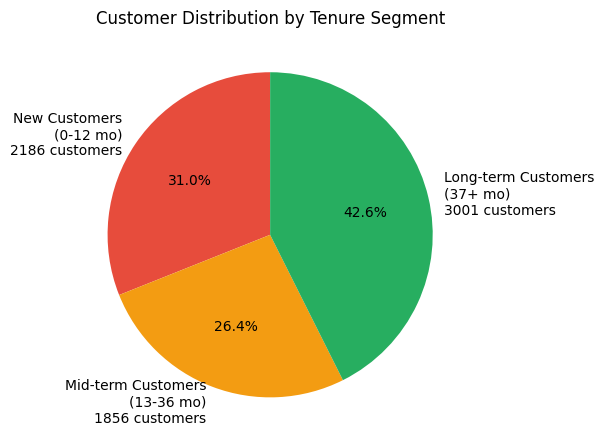

In [18]:
# Pie Chart — Customer Distribution by Tenure Segment
segment_colors= ['#e74c3c', '#f39c12', '#27ae60']
labels=[f'New Customers\n(0-12 mo)\n{segment_counts.iloc[0]} customers',
        f'Mid-term Customers\n(13-36 mo)\n{segment_counts.iloc[1]} customers',
        f'Long-term Customers\n(37+ mo)\n{segment_counts.iloc[2]} customers']

fig, ax= plt.subplots(figsize=(6, 6))

ax.pie(segment_counts.values,
          labels=labels,
          autopct= '%1.1f%%',
          colors= segment_colors,
          startangle= 90)

ax.set_title('Customer Distribution by Tenure Segment')

plt.tight_layout()
plt.show()

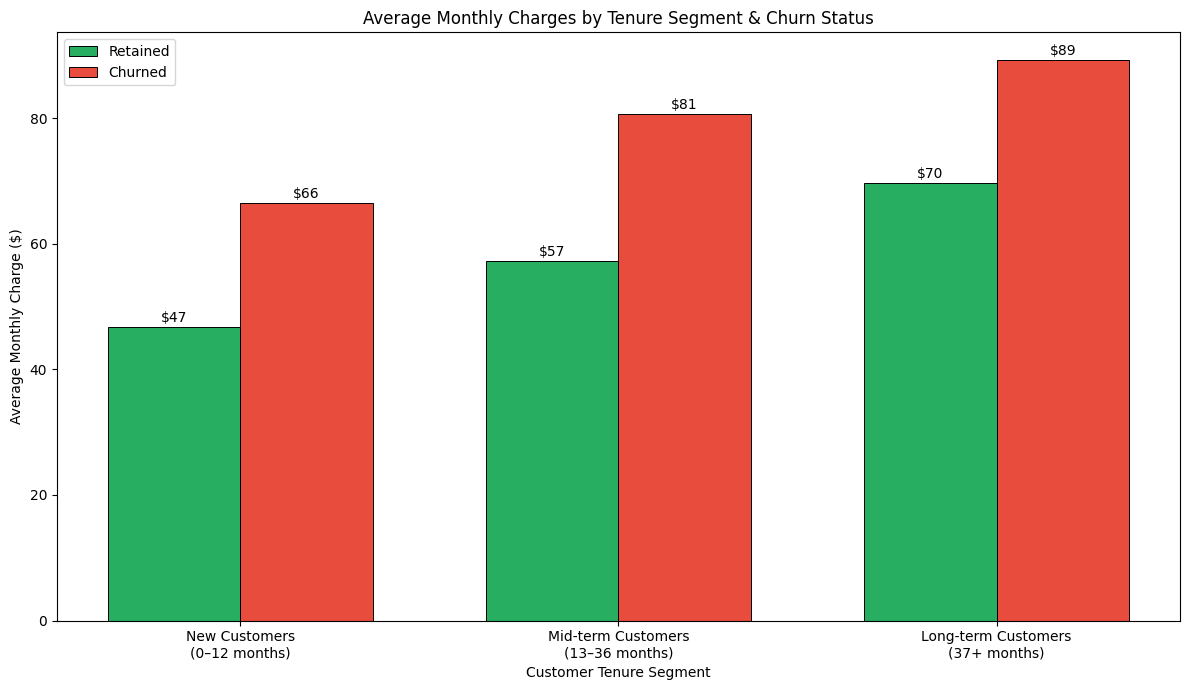

In [25]:
# Clustered Bar Chart — Avg Monthly Charges by Segment
x= np.arange(len(segment_order))
width= 0.35

fig, ax= plt.subplots(figsize=(12, 7))
bars_no  = ax.bar(x - width/2, grouped['No'],  width,
                  label='Retained', color='#27ae60', edgecolor='black', linewidth=0.7)
bars_yes = ax.bar(x + width/2, grouped['Yes'], width,
                  label='Churned', color='#e74c3c', edgecolor='black', linewidth=0.7)
# labels on top of each bar
for bar in bars_no:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f'${bar.get_height():.0f}',
            ha='center')
for bar in bars_yes:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f'${bar.get_height():.0f}',
            ha='center')
ax.set_title('Average Monthly Charges by Tenure Segment & Churn Status')
ax.set_xlabel('Customer Tenure Segment')
ax.set_ylabel('Average Monthly Charge ($)')
ax.set_xticks(x)
ax.set_xticklabels([
    'New Customers\n(0–12 months)',
    'Mid-term Customers\n(13–36 months)',
    'Long-term Customers\n(37+ months)'])
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()
